In [1]:
import pandas as pd
import os
import sys

import geojson
from shapely import Polygon

project_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_dir)

from src.io import *
from src.geometry import *
from src.utils import *
from src.viz import *
from src.core import *
from src.tests import *

In [2]:
region = 'contiguous/world'
level = 'original_world'
# region = 'usa'
# level = 'states'

In [3]:
data, polygons, target_areas, target_positions, names, centroid = loader(region, level, year=2016)

Matched name column: 'ISO_CODE', value column: 'Population (people)'
Number of unmatched regions for year 2016: 0


In [4]:
print(data)

{'AFG': {'area': 62.55305451794993, 'polygon': array([[74.889862, 37.23409 ],
       [74.749411, 37.284587],
       [74.658309, 37.234413],
       [74.500896, 37.239261],
       [74.460624, 37.129476],
       [74.564626, 37.030852],
       [74.419329, 37.007322],
       [74.309291, 36.918906],
       [74.180747, 36.916499],
       [74.12079 , 36.83822 ],
       [73.95743 , 36.842518],
       [73.890465, 36.912521],
       [73.547938, 36.891054],
       [73.082922, 36.887155],
       [72.930033, 36.842962],
       [72.561291, 36.828968],
       [72.502744, 36.783832],
       [72.25347 , 36.752535],
       [72.096512, 36.647102],
       [72.088202, 36.596629],
       [71.809566, 36.507759],
       [71.656951, 36.483566],
       [71.583245, 36.345102],
       [71.450456, 36.272178],
       [71.196903, 36.041247],
       [71.47766 , 35.82171 ],
       [71.55323 , 35.72274 ],
       [71.52111 , 35.60634 ],
       [71.6204  , 35.57123 ],
       [71.65532 , 35.43723 ],
       [71.54304 , 35.3

In [5]:
print(target_areas)

[38326027.0, 66951174.0, 2872130.0, 43090987.0, 335388238.0, 92377.0, 44908441.0, 77020.0, 32898997.0, 2812496.0, 17402277.0, 25544179.0, 8901106.0, 10273528.0, 405779.0, 280427.0, 9661044.0, 11541273.0, 392426.0, 770004.0, 11862346.0, 3340974.0, 2523541.0, 5367955.0, 50617028.0, 798326.0, 212564935.0, 64457760.0, 91331950.0, 5635288.0, 5026496.0, 439893.0, 7020235.0, 21231893.0, 12053897.0, 579933.0, 16296280.0, 26137129.0, 37758232.0, 5105359.0, 26477574.0, 4114639.0, 11309236.0, 5272026.0, 16379185.0, 19206688.0, 1423998019.0, 1233778.0, 10537911.0, 5810778.0, 1082344.0, 71764.0, 10939347.0, 17487163.0, 106538719.0, 6280922.0, 1578373.0, 3523653.0, 1329086.0, 115638360.0, 918091.0, 5525215.0, 2267995.0, 2541049.0, 36488843.0, 30720752.0, 2467077.0, 3769183.0, 83267655.0, 31849246.0, 10543346.0, 55934.0, 123159.0, 12216.0, 17231172.0, 28999227.0, 13041586.0, 1993303.0, 791842.0, 11234508.0, 10817077.0, 10041790.0, 9770120.0, 364340.0, 270825848.0, 86990162.0, 42042951.0, 4925074.0, 1

In [6]:
# plot_polys(polygons, title="Original Polygons", legend=False)

In [7]:
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical_center(polygons)

In [8]:
fixed_points = [np.mean(p, axis=0) for p in polygons]
neighbours   = neighbouring_pairs(polygons)
shared_verts = shared_vertices_of_neighbors(polygons)

Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 1463.92


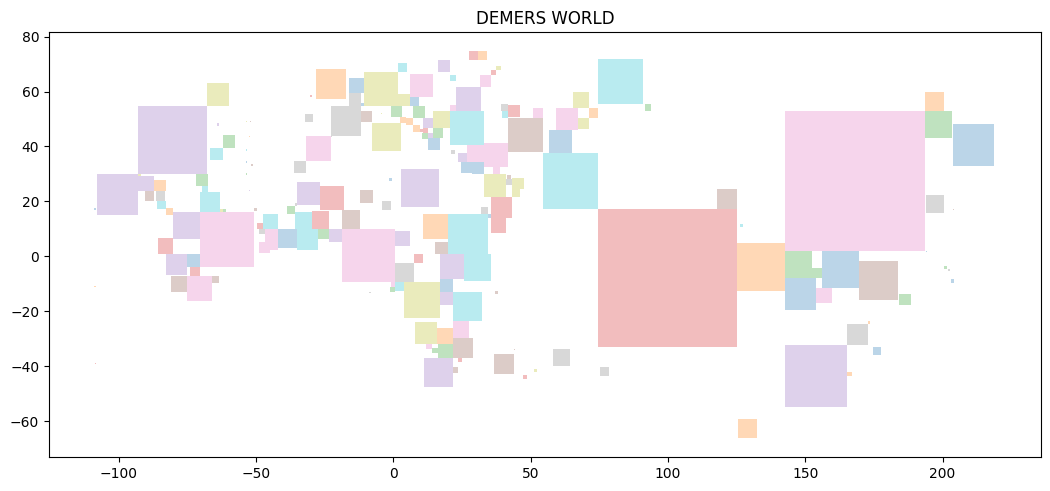

In [9]:
# DEMERS
new_data = CartogramFramework_global(
        data,
        # polygons=polygons,
        # target_areas=target_areas,
        fixed_points=None,             # → uses polygon centroids as origins
        shape="square",             # "circle", "square", or "contiguous"
        target_centers=target_positions,
        horizontal_pairs=horizontal_pairs,
        vertical_pairs=vertical_pairs,
        neighboring_pairs=neighbouring_pairs(polygons),
        shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

        lambda_shape=0.1,    # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
        lambda_area=1.0,      # Demers 1.0
        lambda_center=0.0,    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
        lambda_topology=1.0,  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

        gamma=0.0,            # pure E_square — REQUIRED for Demers
        beta=1.0,
        alpha=1.0,
        epsilon=1e-2,
        b=1e-2,
        t_min=0.01,
        shape_deformation=0.0,  # triggers make_square() until patch is applied
    )
plot_polys_data(new_data,  title="DEMERS WORLD", centroids=False, legend=False, target_centers=None, svg=True)
# plot_polys(new_polys, title="DEMERS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

In [10]:
print(data.keys())
print(data['AFG'].keys())

dict_keys(['AFG', 'GBR', 'ALB', 'DZA', 'USA', 'ATG', 'ARG', 'AND', 'AGO', 'ARM', 'NLD', 'AUS', 'AUT', 'AZE', 'BHS', 'BRB', 'BLR', 'BEL', 'BLZ', 'BTN', 'BOL', 'BIH', 'BWA', 'NOR', 'COL', 'COM', 'BRA', 'FRA', 'COD', 'COG', 'NZL', 'BRN', 'BGR', 'BFA', 'BDI', 'CPV', 'KHM', 'CMR', 'CAN', 'CRI', 'CIV', 'HRV', 'CUB', 'CAF', 'TCD', 'CHL', 'CHN', 'CYP', 'CZE', 'DNK', 'DJI', 'DMA', 'DOM', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI', 'EST', 'ETH', 'FJI', 'FIN', 'GAB', 'GMB', 'MAR', 'MOZ', 'NAM', 'GEO', 'DEU', 'GHA', 'GRC', 'GRL', 'GRD', 'NRU', 'GTM', 'NPL', 'GIN', 'GNB', 'GUY', 'HTI', 'JOR', 'HND', 'HUN', 'ISL', 'IDN', 'IRN', 'IRQ', 'IRL', 'KAZ', 'KEN', 'KIR', 'PRK', 'KOR', 'XKX', 'SRB', 'SYC', 'SLE', 'SGP', 'ITA', 'JAM', 'JPN', 'KGZ', 'LAO', 'LVA', 'LBN', 'LSO', 'LBR', 'LBY', 'LIE', 'LTU', 'LUX', 'MCO', 'MNG', 'MNE', 'MKD', 'MDG', 'MWI', 'MYS', 'MDV', 'MLI', 'MLT', 'MHL', 'MRT', 'MUS', 'MEX', 'FSM', 'MDA', 'NIC', 'OMN', 'PAK', 'PLW', 'PAN', 'PNG', 'PRY', 'PER', 'PHL', 'POL', 'PRT', 'ROU', 'RUS', 'RWA', 'W

Contiguous mode 'circle': 0 shared-vertex penalty terms added.


/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_data.py:683: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob = cp.Problem(objective, constraints)


Status : optimal
Obj val: 44661.8


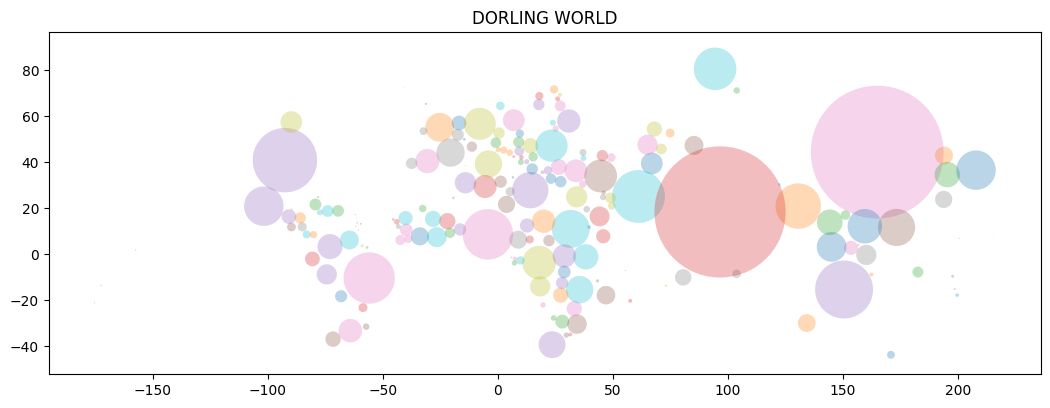

In [11]:
# DORLING Test
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "circle",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

    lambda_shape    = 0.1,   # small — circles form without needing shape pressure
    lambda_area     = 1.0,
    lambda_center   = 0.5,   # moderate centre fidelity keeps circles near geography
    lambda_topology = 1.0,

    gamma = 0.0,   # REQUIRED — pure E_circle
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
    t_min   = 0.01,
    t_max   = 5.0,
    shape_deformation = 0.0,   # triggers make_circle()
)
plot_polys_data(new_data, title="DORLING WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 1.41326e-13


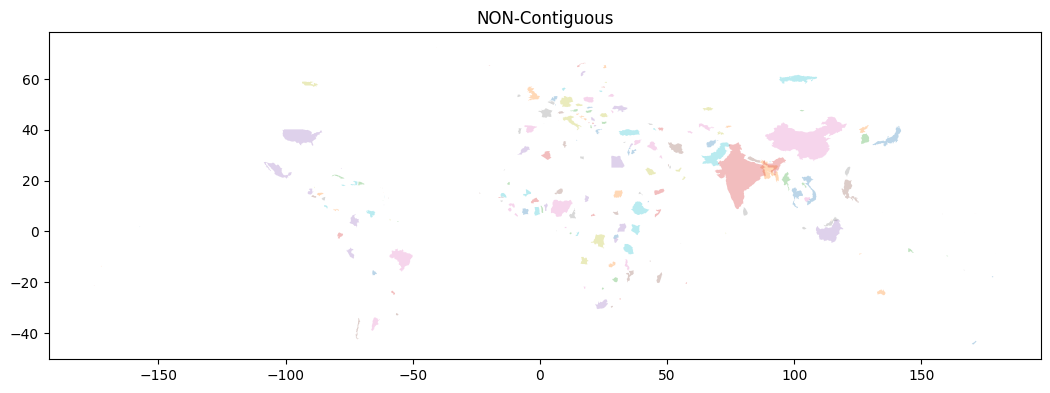

In [16]:
new_data = CartogramFramework_global(
    data=data,
    shape="original",

    target_centers=None,          # don't move the centroids yet

    neighboring_pairs=None,
    horizontal_pairs=None,
    vertical_pairs=None,
    shared_vertices_of_neighbors=None,
    soft_mean_scale=True,

    lambda_shape=0.0,             # let area scaling dominate for shrinkage
    lambda_area=1.0,              # keep the soft mean-scale / area target active
    lambda_center=0.0,
    lambda_topology=0.0,

    area_scale=0.1,

    gamma=1.0,
    beta=1.0,

    t_min=1e-8,
    t_max=10000.0,
)
plot_polys_data(new_data, title="NON-Contiguous", centroids=False, legend=False, target_centers=None)

Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : infeasible
Obj val: inf
  Tips for contiguous mode:
    • Raise contiguous_area_ratio_cap (skips locking large-ratio pairs)
    • Set contiguous_use_topology=False to drop topology terms
    • Switch to shape='contiguous2' (soft penalty instead of hard equality)


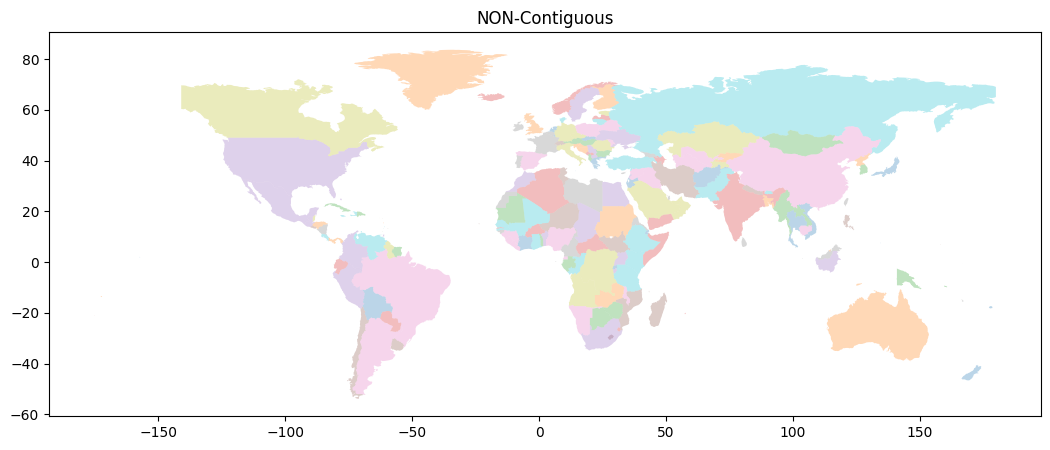

In [13]:
new_data = CartogramFramework_global(
    data         = data,
    # target_areas     = target_areas,
    fixed_points     = None,
    shape            = "original",
    target_centers   = target_positions,
    horizontal_pairs = None,   # no ordering — just scale in place
    vertical_pairs   = None,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = None,

    lambda_shape    = 1.0,
    lambda_area     = 1.0,
    lambda_center   = 0.5,   # moderate pull keeps regions near original position
    lambda_topology = 0.0,   # OFF — ordering was causing infeasibility

    area_scale = 0.1,

    gamma = 1.0,
    beta  = 1.0,
    t_min = 0.01,
    t_max = 25000.0,   # large — some regions may need to grow a lot
)
plot_polys_data(new_data, title="NON-Contiguous", centroids=False, legend=False, target_centers=None)

In [14]:
# Test with Cartogram Framework 0 without post processing
new_data = CartogramFramework_global(
    data        = data,
    fixed_points    = None,
    shape           = "contiguous",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,       # only for contiguous2 The higher the closer to contiguous
    soft_mean_scale   = True,       # Makes mean(t) = s soft not hard
    lambda_mean_scale = 1e-10,        # Weight of the hardness of soft_mean_scale. The higher the closer to soft_mean_scale = False
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
)
plot_polys_data(new_data, title="REAL CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

KeyboardInterrupt: 

Contiguous mode 'contiguous2': 9322 shared-vertex penalty terms added.


/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_data.py:684: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob.solve(solver=cp.CLARABEL, verbose=False)


Status : optimal
Obj val: 1.76364e+07


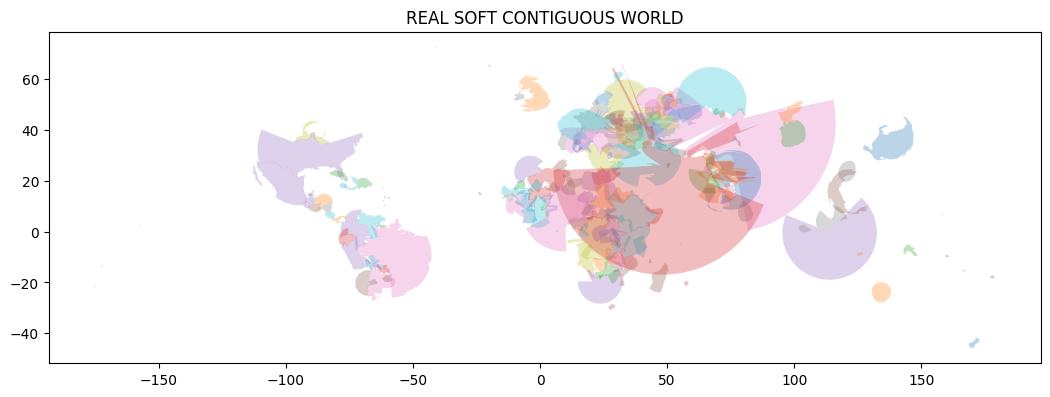

In [ ]:
# Test with Cartogram Framework 0 without post processing
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,       # only for contiguous2 The higher the closer to contiguous
    soft_mean_scale   = True,       # Makes mean(t) = s soft not hard
    lambda_mean_scale = 1e4,        # Weight of the hardness of soft_mean_scale. The higher the closer to soft_mean_scale = False
    t_min = 0.01,
    t_max = 15,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
)
plot_polys_data(new_data, title="REAL SOFT CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'contiguous2': 9322 shared-vertex penalty terms added.
Status : optimal
Obj val: 4.44426e+07


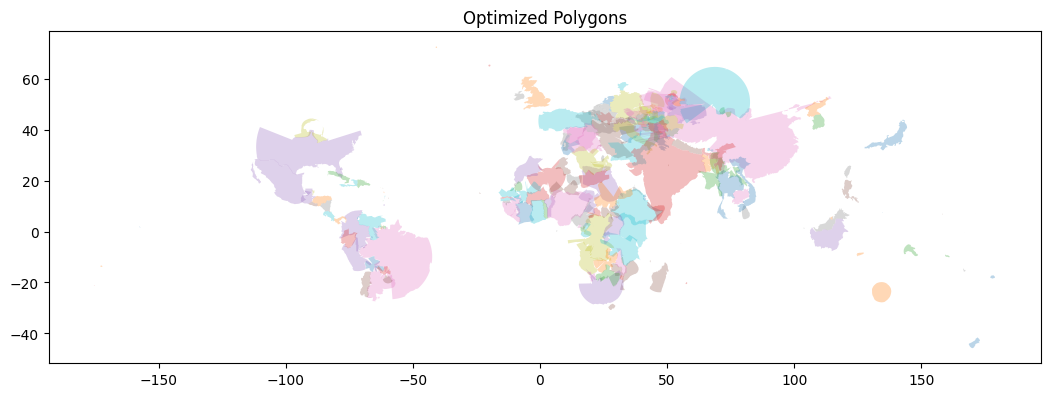

In [ ]:
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,
    soft_mean_scale   = True,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,

    # ── Post-processing ───────────────────────────────────────────
    postprocess_contiguous  = False,     # flip to False to skip entirely
    postprocess_snap_method = "mean",   # midpoint snap on shared vertices
)
plot_polys_data(new_data, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Try all lambdas 0


In [ ]:
# new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
#     polygons,
#     target_areas,
#     fixed_points=None,
#     shape="contiguous2",
#     target_centers=None,
#     horizontal_pairs=None,            # list[(i,j)] i left of j
#     vertical_pairs=None,              # list[(i,j)] i below j
#     neighboring_pairs=None,           # list[(i,j)] geographically adjacent
#     shared_vertices_of_neighbors=None,

#     # --- objective weights (λ) ---
#     lambda_shape= 0.0,     # λ_s  shape deformation
#     lambda_area= 0.0,     # λ_a  cartographic error (soft)
#     lambda_center= 0.0,     # λ_c  centre fidelity
#     lambda_topology= 0.0,     # λ_t  pairwise topology

#     lambda_contiguous= 0.0,
#     contiguous_area_ratio_cap= 10.0,
#     contiguous_use_topology= True,
#     gamma= 1.0,   # 1 = pure deformation term, 0 = pure E_target
#     beta= 1.0,
#     alpha= 1.0,   # slope for diagonal deviation d_ij
#     epsilon= 1e-2,  # gap for non-adjacent pairs
#     b= 1e-2,  # scale for directional weight b_ij
#     t_min= 0.01,  # minimum radial scale
#     t_max= 5.0,
#     cartographic_error= 0.0,
#     shape_deformation= 0.0,
#     relative_direction= 0.0,
#     topological_accuracy= 0.0,
#     spatial_deformation= 0.0,
#     global_shape= 0.0,
#     local_shape= 0.0,
#     complexity= 0.0,
#     data_ink_ratio= 0.0,
#     area_scale= 0.0,
#     postprocess_contiguous= False,
#     postprocess_snap_method= "mean",
#     compute_leaders_flag= True,
#     leader_tol= 1e-3,
#     soft_mean_scale= False,
#     lambda_mean_scale= 1e4,
#     lambda_repulsion= 0.0,
#     repulsion_only_adjacent= False,
#     repulsion_margin= 1.0,
#     lambda_vertex_distance= 0.0,
#     vertex_distance_margin= 1.5,
#     postprocess_resolve_overlaps= False,
# )
# plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Last Output from last meeting

Contiguous mode 'contiguous2': 9322 shared-vertex penalty terms added.
Status : optimal
Obj val: 4.44426e+07
Post-processing: snapping shared vertices (method='mean')


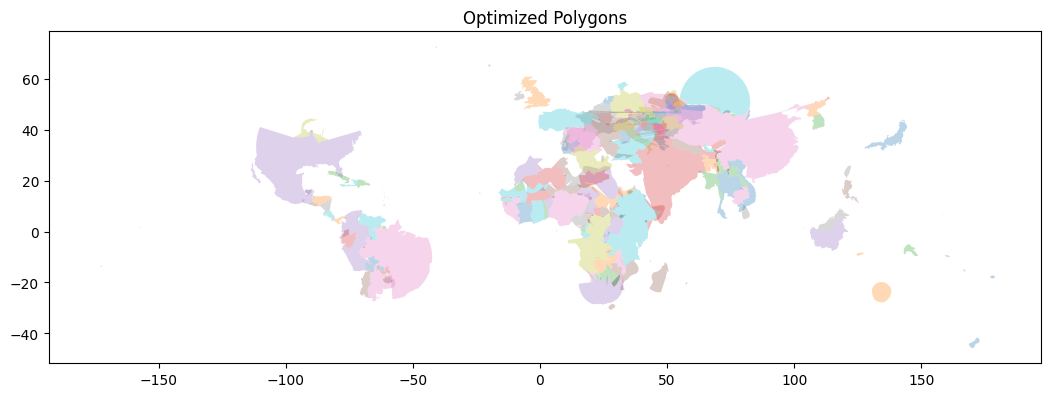

In [ ]:
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,
    soft_mean_scale   = True,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,

    # ── Post-processing ───────────────────────────────────────────
    postprocess_contiguous  = True,     # flip to False to skip entirely
    postprocess_snap_method = "mean",   # midpoint snap on shared vertices
)
plot_polys_data(new_data, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

Contiguous mode 'contiguous2': 9322 shared-vertex penalty terms added.
Status : optimal
Obj val: 4.44426e+07


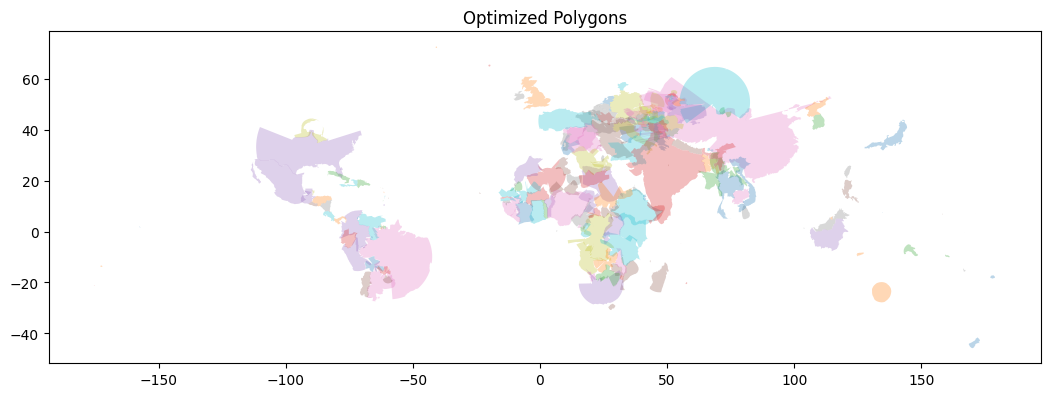

In [ ]:
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,
    soft_mean_scale   = True,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,

    # ── Post-processing ───────────────────────────────────────────
    postprocess_contiguous  = False,     # flip to False to skip entirely
    postprocess_snap_method = "mean",   # midpoint snap on shared vertices
)
plot_polys_data(new_data, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

In [ ]:
# original_areas = [polygon_areanp(poly) for poly in polygons]

# for area, target_area, original_area in zip(areas, target_areas, original_areas):
#     print(f"Area: {area:.2f}, Target Area: {target_area:.2f}, Difference: {abs(area - target_area):.2f}")
#     print(f"Original Area: {original_area:.2f}, Difference from Original: {abs(area - original_area):.2f}")


In [ ]:
base_path = "/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/"
path = os.path.join(base_path, "data/geojson/contiguous/world/world.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_ncont.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_dorling.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_cont.geojson")

In [ ]:
polygons, target_areas, target_positions, names, centroid = get_polygon_data(path, exclude=None)
# print(polygons)
plot_polys(polygons, title="COntiguous Polygons", legend=False)

TypeError: get_polygon_data() missing 1 required positional argument: 'data'

In [ ]:
def cartographic_error(df, polygons, names, index=None):
    if index is not None:
        df = df.set_index("ISO_CODE")
    total_target = 0
    total_area = 0
    normalized_area = []
    error_cartographic = []

    for polygon, name in zip(polygons, names):
        target = df.loc[name, "Population (people)"]
        total_target += target
        total_area += polygon_areanp(polygon)

    c = total_area/total_target
    
    for polygon, name in zip(polygons, names):
        target = df.loc[name, "Population (people)"]
        norm_area = polygon_areanp(polygon)/c
        normalized_area.append(norm_area)

        e_cartographic = abs(norm_area - target) / norm_area
        error_cartographic.append(e_cartographic)

    e_c = pd.Series(error_cartographic)
    print(e_c.describe())

    return error_cartographic


In [ ]:
df = pd.read_csv(os.path.join(base_path, "data/statistics/contiguous/world/world.csv"))
df = df.set_index("ISO_CODE")

In [ ]:
f = cartographic_error(df, new_polys, names)

count      157.000000
mean      1019.279080
std       7595.670741
min          0.055354
25%          0.666100
50%          0.953332
75%         10.374358
max      80665.497572
dtype: float64


In [ ]:
m = cartographic_error(df, polygons, names)

count    157.000000
mean       0.289738
std        1.206952
min        0.001673
25%        0.069825
50%        0.076339
75%        0.144601
max       14.804221
dtype: float64


In [ ]:
total_target = 0
total_area = 0
for polygon, name in zip(polygons, names):
    poly = Polygon(polygon)
    target = df.loc[name, "Population (people)"]
    total_target += target
    total_area += poly.area
    # print(f"Polygon: {name}, Target: {target}, Area: {polygon_areanp(polygon):.2f}, Shapely Area: {poly.area:.2f}")

In [ ]:
c = total_area/total_target
normalized_area = []
error_cartographic = []
for polygon, name in zip(polygons, names):
    target = df.loc[name, "Population (people)"]
    norm_area = polygon_areanp(polygon)/c
    normalized_area.append(norm_area)

    e_cartographic = abs(norm_area - target) / norm_area
    error_cartographic.append(e_cartographic)
print(error_cartographic)

[np.float64(0.1446005007150347), np.float64(0.07088310458524742), np.float64(0.07374980129565556), np.float64(0.08092248967294775), np.float64(0.2163898797162552), np.float64(0.06021111529701534), np.float64(0.05900185988909726), np.float64(0.07159498518273548), np.float64(0.03952915330813458), np.float64(0.3825566142741883), np.float64(0.06998173893130914), np.float64(1.065035593791076), np.float64(0.06987749195353209), np.float64(0.07425423673426121), np.float64(0.08566190425550618), np.float64(0.5800380596998633), np.float64(0.06282583654821523), np.float64(0.09627248048201918), np.float64(0.22015870116088493), np.float64(0.27511595252325555), np.float64(0.07138283011077112), np.float64(0.06813667433009507), np.float64(0.7532108643275424), np.float64(0.056425871035337874), np.float64(0.22401205242265837), np.float64(0.02911704277635672), np.float64(0.07246519910669078), np.float64(0.004116785788059389), np.float64(0.08508617299553399), np.float64(0.1405288065113283), np.float64(0.07

In [ ]:
for polygon, name in zip(polygons, names):
    target = df.loc[name, "Population (people)"]
    poly = Polygon(polygon)
    print(f"Error: {target/total_target - poly.area/total_area:.2f}")

Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.01
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.01
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: 0.01
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00